# 02 · Transfer Learning & Model Comparison
## Binary Skin-Lesion Triage — Benign vs. Malignant

*Applied Deep Learning — **Phase 3** (Model Development & Optimization)*

---

**This notebook is a direct continuation of `01_Data_Preparation_and_Baseline`.** It regenerates
**nothing** from Phase 1: it loads the processed split CSVs (with the persisted `image_path`), the
train-derived normalization statistics, the frozen label mapping and the trained baseline checkpoint,
and reuses Notebook 1's *exact* preprocessing, augmentation, DataLoader, loss and evaluation code.
The only thing that changes between experiments is the **one variable under study** — the backbone
(Section 4), the optimizer (Section 5), or the learning rate (Section 6).

### Deliberate design decisions (stated for the graders)

1. **Identical pipeline for every architecture — including the pretrained ones.** All models train at
   **224×224** with Notebook 1's **train-derived** channel statistics, the same Albumentations
   pipeline, the same weighted sampler, the same MixUp/CutMix, the same focal loss, the same EMA +
   warmup-cosine schedule, and the same four-view TTA evaluation. This is what makes the comparison
   *fair*: architecture is the sole difference. **Caveat:** a pretrained ImageNet backbone is
   normally fed its own official recipe (e.g. EfficientNet-B3 at 300px with ImageNet mean/std).
   Holding preprocessing constant means the backbones don't get that recipe; fine-tuning adapts
   their BatchNorm statistics and weights to the shared normalization within a few epochs. We accept
   this because a controlled single-variable comparison is worth more here than each backbone's
   individually-optimal input.
2. **EfficientNet-B0**, not B3 — B0 is the compound-scaling point designed for 224px input, which is
   the frozen size from Notebook 1. (The backbone name is a one-line change if you prefer another.)
3. **One reusable training framework** (`run_experiment`) drives every model; there is no per-model
   training or evaluation code. This satisfies "no duplicated code" and guarantees every run is
   scored by identical logic.

### Compute budget (read before running)
Transfer learning converges faster than the from-scratch baseline, so the main comparison uses a
smaller epoch cap than Notebook 1's 60, with early stopping. The ablation studies (Sections 5–7) use
a further-reduced budget — this is still fair because *every run within a study shares the same
budget*. All epoch caps are configuration constants at the top of Section 1; lower them for a quick
dry-run, raise them for final numbers.

## Section 1 · Load Project Assets

Everything here comes from Notebook 1. We **load** the data artifacts it produced (split CSVs,
normalization statistics, label mapping, baseline checkpoint) and **re-declare its utilities
verbatim** (seeding, transforms, dataset, DataLoader, MixUp/CutMix, focal loss, EMA, scheduler,
training/validation loops, TTA evaluation). A notebook cannot import another notebook's in-memory
objects, so the shared code is defined once here and reused for *all* models — no preprocessing is
recomputed, and the values that define the pipeline (the split, the normalization constants, the
image size, the class mapping) are read from disk, never regenerated.

In [1]:
import os
import math
import time
import json as _json
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import LambdaLR
from torch.amp import autocast, GradScaler

import torchvision
from torchvision import models as tv_models

from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score, recall_score, precision_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)

warnings.filterwarnings("ignore")

# Publication-quality default figure style (applied to every plot in this notebook).
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "legend.frameon": False,
})
print("torch:", torch.__version__, "| torchvision:", torchvision.__version__)

d:\My_GPU_Project\my_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.5.1+cu121 | torchvision: 0.20.1+cu121


In [2]:
# ---------------------------------------------------------------------------
# Reproducibility utilities - identical to Notebook 1 (project-wide standard).
# ---------------------------------------------------------------------------
def seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id: int):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_generator(seed: int) -> torch.Generator:
    g = torch.Generator()
    g.manual_seed(seed)
    return g

In [3]:
# ===========================================================================
# CONFIG - frozen values inherited from Notebook 1 + this notebook's experiment budget.
# Only OUTPUT_DIR must match where Notebook 1 wrote its outputs.
# ===========================================================================
OUTPUT_DIR = Path(r"D:\archive\outputs")     # <-- must equal Notebook 1's OUTPUT_DIR
assert OUTPUT_DIR.exists(), f"{OUTPUT_DIR} not found - run Notebook 1 first."

# ------- Frozen from Notebook 1 (do NOT change) -------
RANDOM_STATE = 42
TARGET_SIZE = (224, 224)      # same image size as Notebook 1
BATCH_SIZE = 32
NUM_WORKERS = 0
LABEL_COL = "binary_encoded"

# Regularization / loss (same as Notebook 1)
WARMUP_FRAC = 0.05
GRAD_CLIP_NORM = 1.0
MIXUP_ALPHA = 0.2
CUTMIX_ALPHA = 1.0
MIX_PROB = 0.25
EMA_DECAY = 0.999
LABEL_SMOOTHING = 0.05
FOCAL_GAMMA = 2.0

# ------- Default training hyperparameters (the experiment BASELINE point) -------
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 5e-4

# ------- Experiment compute budget (safe to tune) -------
EPOCHS_MAIN = 30         # architecture comparison (Section 4)
EPOCHS_ABLATION = 10     # optimizer / LR / extra-HP studies (Sections 5-7)
PATIENCE = 8             # early-stopping patience for this notebook's runs

# ------- Toggles for the heavy ablation sections -------
RUN_OPTIMIZER_STUDY = True
RUN_LR_STUDY = True
RUN_WD_STUDY = True      # Section 7 (optional)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [4]:
# --- Load the frozen data artifacts produced by Notebook 1 (no regeneration) ---
# Normalization: loaded from disk, NOT recomputed -> identical to Notebook 1.
with open(OUTPUT_DIR / "norm_stats.json") as f:
    _norm = _json.load(f)
NORM_MEAN, NORM_STD = tuple(_norm["mean"]), tuple(_norm["std"])

# Label mapping: benign=0, malignant=1 (frozen).
with open(OUTPUT_DIR / "label_mappings_binary.json") as f:
    _label_map = _json.load(f)
BINARY_CLASS_NAMES = [k for k, _ in sorted(_label_map.items(), key=lambda kv: kv[1])]
NUM_CLASSES = len(BINARY_CLASS_NAMES)

# Processed splits (with persisted image_path).
df_train = pd.read_csv(OUTPUT_DIR / "train_metadata.csv")
df_val = pd.read_csv(OUTPUT_DIR / "val_metadata.csv")
df_test = pd.read_csv(OUTPUT_DIR / "test_metadata.csv")

# Integrity checks: same split, paths present, no leakage - fail loudly otherwise.
for name, d in [("train", df_train), ("val", df_val), ("test", df_test)]:
    assert "image_path" in d.columns and d["image_path"].notna().all(), f"{name}: image_path missing"
    assert LABEL_COL in d.columns, f"{name}: {LABEL_COL} missing"
tr, va, te = set(df_train["lesion_id"]), set(df_val["lesion_id"]), set(df_test["lesion_id"])
assert not (tr & va) and not (tr & te) and not (va & te), "Leakage across splits detected!"

print("Loaded Notebook 1 assets:")
print(f"  NORM_MEAN={NORM_MEAN}  NORM_STD={NORM_STD}")
print(f"  classes (index order): {BINARY_CLASS_NAMES}")
print(f"  train={len(df_train)}  val={len(df_val)}  test={len(df_test)}")
print("  split integrity + leakage checks: PASS")

Loaded Notebook 1 assets:
  NORM_MEAN=(0.72264, 0.53399, 0.54885)  NORM_STD=(0.1903, 0.17615, 0.19192)
  classes (index order): ['benign', 'malignant']
  train=9231  val=1847  test=1846
  split integrity + leakage checks: PASS


In [5]:
# ---------------------------------------------------------------------------
# Transforms - identical to Notebook 1 (same resize, same train-derived norm,
# same augmentation, same deterministic 4-view TTA).
# ---------------------------------------------------------------------------
def build_train_transform() -> A.Compose:
    return A.Compose([
        A.Resize(*TARGET_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.15, rotate_limit=20, p=0.6),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10),
            A.CLAHE(clip_limit=2.0),
        ], p=0.5),
        A.OneOf([
            A.GaussNoise(var_limit=(5.0, 20.0)),
            A.GaussianBlur(blur_limit=3),
        ], p=0.2),
        A.CoarseDropout(max_holes=6, max_height=16, max_width=16, min_holes=1, p=0.3),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2(),
    ])


def build_eval_transform() -> A.Compose:
    return A.Compose([
        A.Resize(*TARGET_SIZE),
        A.Normalize(mean=NORM_MEAN, std=NORM_STD),
        ToTensorV2(),
    ])


def build_tta_transforms() -> list:
    tail = [A.Resize(*TARGET_SIZE), A.Normalize(mean=NORM_MEAN, std=NORM_STD), ToTensorV2()]
    return [
        A.Compose(tail),
        A.Compose([A.HorizontalFlip(p=1.0)] + tail),
        A.Compose([A.VerticalFlip(p=1.0)] + tail),
        A.Compose([A.HorizontalFlip(p=1.0), A.VerticalFlip(p=1.0)] + tail),
    ]

In [6]:
# ---------------------------------------------------------------------------
# Dataset + DataLoader - identical behaviour to Notebook 1. The Dataset reads the
# persisted `image_path` column directly (that is exactly why Notebook 1 saved it),
# so no image-directory search is needed here.
# ---------------------------------------------------------------------------
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform: A.Compose, label_col: str):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = np.array(Image.open(row["image_path"]).convert("RGB"))
        image = self.transform(image=image)["image"]
        return image, int(row[self.label_col])


def compute_class_sample_weights(df, label_col, power=0.5):
    counts = df[label_col].value_counts().to_dict()
    inv_freq = {c: (1.0 / n) ** power for c, n in counts.items()}
    return df[label_col].map(inv_freq).values


def build_dataloaders(label_col: str):
    train_ds = SkinLesionDataset(df_train, build_train_transform(), label_col)
    val_ds = SkinLesionDataset(df_val, build_eval_transform(), label_col)
    test_ds = SkinLesionDataset(df_test, build_eval_transform(), label_col)

    sample_weights = compute_class_sample_weights(df_train, label_col)
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights),
                                    replacement=True, generator=make_generator(RANDOM_STATE))
    gen = make_generator(RANDOM_STATE)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
                              worker_init_fn=seed_worker, generator=gen)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True, worker_init_fn=seed_worker)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True, worker_init_fn=seed_worker)
    return train_loader, val_loader, test_loader

In [7]:
# ---------------------------------------------------------------------------
# MixUp/CutMix, Focal loss, EMA, scheduler, epoch loops, fit() - verbatim from Notebook 1.
# ---------------------------------------------------------------------------
def rand_bbox(size, lam):
    H, W = size[2], size[3]
    cut_rat = np.sqrt(1.0 - lam)
    cut_h, cut_w = int(H * cut_rat), int(W * cut_rat)
    cy, cx = np.random.randint(H), np.random.randint(W)
    y1, y2 = np.clip(cy - cut_h // 2, 0, H), np.clip(cy + cut_h // 2, 0, H)
    x1, x2 = np.clip(cx - cut_w // 2, 0, W), np.clip(cx + cut_w // 2, 0, W)
    return x1, y1, x2, y2


def mixup_cutmix(images, labels):
    if np.random.rand() > MIX_PROB:
        return images, labels, labels, 1.0
    perm = torch.randperm(images.size(0), device=images.device)
    labels_b = labels[perm]
    if np.random.rand() < 0.5:
        lam = np.random.beta(CUTMIX_ALPHA, CUTMIX_ALPHA)
        x1, y1, x2, y2 = rand_bbox(images.size(), lam)
        images[:, :, y1:y2, x1:x2] = images[perm][:, :, y1:y2, x1:x2]
        lam = 1 - ((x2 - x1) * (y2 - y1) / (images.size(-1) * images.size(-2)))
    else:
        lam = np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA)
        images = lam * images + (1 - lam) * images[perm]
    return images, labels, labels_b, float(lam)


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.alpha, self.gamma, self.label_smoothing = alpha, gamma, label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha,
                             label_smoothing=self.label_smoothing, reduction="none")
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

    def forward_soft(self, logits, targets_a, targets_b, lam):
        return lam * self.forward(logits, targets_a) + (1 - lam) * self.forward(logits, targets_b)


class EMA:
    def __init__(self, model, decay):
        self.decay = decay
        self.params = {n: p.detach().clone() for n, p in model.named_parameters() if p.requires_grad}
        self.buffers = {n: b.detach().clone() for n, b in model.named_buffers()}

    @torch.no_grad()
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad:
                self.params[n].mul_(self.decay).add_(p.detach(), alpha=1 - self.decay)
        for n, b in model.named_buffers():
            self.buffers[n] = b.detach().clone()

    def state_dict(self):
        return {**self.params, **self.buffers}

    def apply_to(self, model):
        model.load_state_dict(self.state_dict(), strict=True)


def build_scheduler(optimizer, steps_per_epoch, num_epochs, warmup_frac):
    total_steps = steps_per_epoch * num_epochs
    warmup_steps = max(1, int(total_steps * warmup_frac))

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))

    return LambdaLR(optimizer, lr_lambda)


def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, ema):
    model.train()
    running_loss, clean_correct, clean_total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        images, targets_a, targets_b, lam = mixup_cutmix(images, labels)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type="cuda", enabled=(DEVICE.type == "cuda")):
            outputs = model(images)
            loss = criterion.forward_soft(outputs, targets_a, targets_b, lam)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        ema.update(model)
        running_loss += loss.item() * images.size(0)
        if lam == 1.0:
            clean_correct += (outputs.argmax(1) == labels).sum().item()
            clean_total += labels.size(0)
    train_acc = clean_correct / clean_total if clean_total else float("nan")
    return running_loss / len(loader.dataset), train_acc


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    running_loss, all_preds, all_labels = 0.0, [], []
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        with autocast(device_type="cuda", enabled=(DEVICE.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        all_preds.append(outputs.argmax(1).cpu())
        all_labels.append(labels.cpu())
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return (running_loss / len(loader.dataset),
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average="macro"))


def fit(model, train_loader, val_loader, criterion, optimizer, scheduler,
        num_epochs, patience, checkpoint_path, verbose=True):
    scaler = GradScaler(enabled=(DEVICE.type == "cuda"))
    ema = EMA(model, EMA_DECAY)
    ema_model = copy.deepcopy(model)
    best_val_f1, epochs_no_improve, history = 0.0, 0, []
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion,
                                                 optimizer, scheduler, scaler, ema)
        ema.apply_to(ema_model)
        val_loss, val_acc, val_f1 = validate(ema_model, val_loader, criterion)
        history.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc,
                        "val_loss": val_loss, "val_acc": val_acc, "val_macro_f1": val_f1})
        if verbose:
            print(f"  epoch {epoch:3d}/{num_epochs} | train_loss={train_loss:.4f} "
                  f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}")
        if val_f1 > best_val_f1:
            best_val_f1, epochs_no_improve = val_f1, 0
            torch.save({"model": model.state_dict(), "ema": ema.state_dict()}, checkpoint_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  early stopping at epoch {epoch}")
                break
    return best_val_f1, pd.DataFrame(history)

In [8]:
# ---------------------------------------------------------------------------
# Evaluation utilities - identical protocol to Notebook 1 (EMA weights, 4-view TTA,
# recall-constrained threshold chosen on VALIDATION only).
# ---------------------------------------------------------------------------
@torch.no_grad()
def tta_predict_probs(model, dataframe, label_col, num_classes):
    model.eval()
    all_probs = np.zeros((len(dataframe), num_classes), dtype=np.float32)
    tta = build_tta_transforms()
    for t in tta:
        ds = SkinLesionDataset(dataframe, t, label_col)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, worker_init_fn=seed_worker)
        view_probs = []
        for images, _ in loader:
            images = images.to(DEVICE)
            with autocast(device_type="cuda", enabled=(DEVICE.type == "cuda")):
                logits = model(images)
            view_probs.append(F.softmax(logits, dim=1).float().cpu().numpy())
        all_probs += np.concatenate(view_probs, axis=0)
    return all_probs / len(tta)


def choose_threshold(model, label_col, num_classes, min_recall=0.88):
    """Recall-constrained best-macro-F1 threshold, chosen on VALIDATION only.
    (Same rule as Notebook 1; does not overwrite Notebook 1's threshold file.)"""
    val_probs = tta_predict_probs(model, df_val, label_col, num_classes)
    y_val = df_val[label_col].values
    best_t, best_f1 = 0.5, -1.0
    for t in np.arange(0.05, 0.96, 0.01):
        preds_t = (val_probs[:, 1] >= t).astype(int)
        if recall_score(y_val, preds_t, pos_label=1) < min_recall:
            continue
        f1 = f1_score(y_val, preds_t, average="macro")
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t


def metrics_from_probs(labels, probs, threshold):
    preds = (probs[:, 1] >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    m = {
        "accuracy": accuracy_score(labels, preds),
        "balanced_accuracy": balanced_accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, pos_label=1, zero_division=0),
        "recall": recall_score(labels, preds, pos_label=1, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else float("nan"),
        "f1": f1_score(labels, preds, pos_label=1, zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "roc_auc": roc_auc_score(labels, probs[:, 1]),
    }
    return m, preds


def count_params(model):
    return int(sum(p.numel() for p in model.parameters()))


def measure_inference_time(model, loader):
    """Average single-view inference latency (ms per image) over the test set."""
    model.eval()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t0, n = time.time(), 0
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(DEVICE)
            with autocast(device_type="cuda", enabled=(DEVICE.type == "cuda")):
                _ = model(images)
            n += images.size(0)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    return (time.time() - t0) * 1000.0 / max(n, 1)


def peak_gpu_mem_mb():
    return torch.cuda.max_memory_allocated() / 1e6 if DEVICE.type == "cuda" else float("nan")

print("Notebook 1 utilities re-declared and data assets loaded. Ready to build models.")

Notebook 1 utilities re-declared and data assets loaded. Ready to build models.


**Results & discussion.** Section 1 confirms the pipeline is *inherited*, not rebuilt: normalization
comes from `norm_stats.json`, the class order from `label_mappings_binary.json`, and the exact same
split from the three CSVs — with `image_path` present and lesion-level disjointness re-asserted. Every
downstream model is therefore trained and scored on identical data through identical code; only the
architecture/optimizer/LR under study will vary.

## Section 2 · Unified Training Framework

A single function, `run_experiment`, is the *only* place training and evaluation happen. Given a
model-builder and a set of hyper-parameters it: re-seeds for reproducibility, builds the shared
DataLoaders, constructs the model, trains with the shared engine (or loads a pre-trained checkpoint
for the baseline), reloads the EMA weights, selects the recall-constrained threshold on validation,
evaluates on the held-out test set with four-view TTA, measures training time / inference latency /
parameter count / peak memory, and saves the checkpoint, per-epoch history, test predictions and a
metrics record. Because every experiment flows through this one function, comparisons are fair by
construction and no training/evaluation code is duplicated per model.

In [9]:
def build_optimizer(name, params, lr, weight_decay):
    name = name.lower()
    if name == "adam":
        return torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=weight_decay, nesterov=True)
    raise ValueError(f"Unknown optimizer: {name}")


def _safe(name):
    return name.replace(" ", "").replace("/", "-")


def run_experiment(exp_name, model_builder, *, optimizer_name="adamw", lr=LEARNING_RATE,
                   weight_decay=WEIGHT_DECAY, epochs=EPOCHS_MAIN, patience=PATIENCE,
                   tag="main", retrain=True, verbose=False):
    """The single reusable training+evaluation routine. Returns (result_dict, history_df)."""
    seed_everything(RANDOM_STATE)                       # identical starting point for every run
    if DEVICE.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    train_loader, val_loader, test_loader = build_dataloaders(LABEL_COL)
    model = model_builder().to(DEVICE)
    n_params = count_params(model)
    ckpt_path = OUTPUT_DIR / f"best_model_{_safe(exp_name)}.pt"

    if retrain:
        criterion = FocalLoss(alpha=None, gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING)
        optimizer = build_optimizer(optimizer_name, model.parameters(), lr, weight_decay)
        scheduler = build_scheduler(optimizer, len(train_loader), epochs, WARMUP_FRAC)
        t0 = time.time()
        best_val_f1, history_df = fit(model, train_loader, val_loader, criterion, optimizer,
                                      scheduler, epochs, patience, ckpt_path, verbose=verbose)
        train_time = time.time() - t0
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE)["ema"])  # deploy EMA weights
        history_df.to_csv(OUTPUT_DIR / f"history_{_safe(exp_name)}.csv", index=False)
    else:
        # Baseline: already trained in Notebook 1 - load, do not retrain.
        best_val_f1, train_time = float("nan"), float("nan")
        hist_path = OUTPUT_DIR / "training_history.csv"
        history_df = pd.read_csv(hist_path) if hist_path.exists() else pd.DataFrame()

    threshold = choose_threshold(model, LABEL_COL, NUM_CLASSES)
    probs = tta_predict_probs(model, df_test, LABEL_COL, NUM_CLASSES)
    labels = df_test[LABEL_COL].values
    m, preds = metrics_from_probs(labels, probs, threshold)
    infer_ms = measure_inference_time(model, test_loader)
    mem_mb = peak_gpu_mem_mb()

    result = {"tag": tag, "model": exp_name, "optimizer": optimizer_name, "lr": lr,
              "weight_decay": weight_decay, "epochs_cap": epochs, "threshold": threshold,
              **m, "train_time_s": train_time, "infer_ms_per_img": infer_ms,
              "n_params": n_params, "peak_mem_mb": mem_mb, "best_val_macro_f1": best_val_f1}

    # Save per-model test predictions (Notebook 3 consumes these for error analysis).
    pd.DataFrame({
        "image_id": df_test["image_id"].values,
        "true_label": labels.astype(int),
        "predicted_label": preds.astype(int),
        "probability_benign": (1 - probs[:, 1]).astype(float),
        "probability_malignant": probs[:, 1].astype(float),
    }).sort_values("image_id").to_csv(OUTPUT_DIR / f"predictions_{_safe(exp_name)}.csv", index=False)

    with open(OUTPUT_DIR / f"result_{_safe(exp_name)}.json", "w") as f:
        _json.dump(result, f, indent=2, default=str)

    print(f"[done] {exp_name:32s} | macroF1={m['macro_f1']:.4f} AUC={m['roc_auc']:.4f} "
          f"recall={m['recall']:.4f} | params={n_params/1e6:.2f}M train={train_time:.1f}s")
    return result, history_df

In [10]:
# --- Publication-quality plotting helpers (defined once, reused everywhere) ---
def plot_learning_curves(histories: dict, title: str, save_name: str):
    """histories: {label -> history_df}. Draws loss, accuracy, val macro-F1 side by side."""
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
    for label, h in histories.items():
        if h is None or len(h) == 0:
            continue
        axes[0].plot(h["epoch"], h["val_loss"], marker="o", ms=3, label=label)
        axes[1].plot(h["epoch"], h["val_acc"], marker="o", ms=3, label=label)
        axes[2].plot(h["epoch"], h["val_macro_f1"], marker="o", ms=3, label=label)
    axes[0].set_title("Validation Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[2].set_title("Validation Macro-F1"); axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Macro-F1")
    for ax in axes:
        ax.legend(fontsize=9)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / save_name)
    plt.show()


def plot_train_val_loss(histories: dict, title: str, save_name: str):
    """Train vs validation loss overlay per model (overfitting diagnostic)."""
    fig, ax = plt.subplots(figsize=(8, 5))
    for label, h in histories.items():
        if h is None or len(h) == 0 or "train_loss" not in h:
            continue
        line, = ax.plot(h["epoch"], h["train_loss"], ls="-", label=f"{label} (train)")
        ax.plot(h["epoch"], h["val_loss"], ls="--", color=line.get_color(), label=f"{label} (val)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title(title); ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / save_name); plt.show()


def grouped_bar(df, index_col, group_col, value_col, title, ylabel, save_name):
    """Grouped bar chart: one cluster per index_col value, one bar per group_col value."""
    pivot = df.pivot(index=index_col, columns=group_col, values=value_col)
    ax = pivot.plot(kind="bar", figsize=(9, 5), edgecolor="black", linewidth=0.4)
    ax.set_title(title); ax.set_ylabel(ylabel); ax.set_xlabel(index_col)
    ax.legend(title=group_col, fontsize=9)
    plt.xticks(rotation=0); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / save_name); plt.show()


def simple_bar(labels, values, title, ylabel, save_name, color="#4C72B0"):
    fig, ax = plt.subplots(figsize=(8, 4.6))
    ax.bar(labels, values, color=color, edgecolor="black", linewidth=0.4)
    ax.set_title(title); ax.set_ylabel(ylabel)
    for i, v in enumerate(values):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    plt.xticks(rotation=20, ha="right"); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / save_name); plt.show()

print("Framework and plotting helpers ready.")

Framework and plotting helpers ready.


**Discussion.** `run_experiment` is deliberately the notebook's single point of truth. Every metric
in every table below is produced by this same code path — identical seeding, identical data order,
identical TTA evaluation and threshold rule — so any measured difference is attributable to the one
variable a section changes, not to incidental differences in training or scoring.

## Section 3 · Model Definitions

Four models, all consumed by the same framework:

1. **CNN Baseline** — the from-scratch ResNet-SE from Notebook 1, **loaded** from
   `best_model_binary.pt` (EMA weights). Not retrained.
2. **EfficientNet-B0**, 3. **ResNet50**, 4. **DenseNet121** — ImageNet-pretrained torchvision
   backbones, each with its classifier replaced by a two-logit head (`Dropout(0.3) → Linear(·, 2)`)
   so it is a drop-in for the same softmax + focal-loss engine. All are fine-tuned end-to-end.

The two-logit head (rather than a single sigmoid logit) is intentional: it keeps every model
compatible with Notebook 1's cross-entropy-based focal loss and its exact evaluation code, so the
baseline and the transfer-learning models are scored by literally the same function.

In [11]:
# --- Baseline architecture (re-declared verbatim so the checkpoint can be loaded) ---
def drop_path(x, drop_prob, training):
    if drop_prob == 0.0 or not training:
        return x
    keep_prob = 1.0 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    mask = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    mask.floor_()
    return x.div(keep_prob) * mask


class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__(); self.drop_prob = drop_prob
    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 8)), nn.ReLU(inplace=False),
            nn.Linear(max(channels // reduction, 8), channels), nn.Sigmoid())
    def forward(self, x):
        b, c, _, _ = x.shape
        return x * self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)


class ResidualSEBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, drop_path_prob=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.se = SEBlock(out_ch)
        self.drop_path = DropPath(drop_path_prob)
        self.shortcut = nn.Identity()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False), nn.BatchNorm2d(out_ch))
    def forward(self, x):
        identity = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=False)
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out = self.drop_path(out)
        return F.relu(out + identity, inplace=False)


class SkinLesionResNetSE(nn.Module):
    def __init__(self, num_classes, base_width=24, dropout=0.3, max_drop_path=0.2):
        super().__init__()
        widths = [base_width, base_width*2, base_width*4, base_width*8, base_width*16]
        blocks_per_stage = [2, 2, 3, 3]
        depth_probs = np.linspace(0, max_drop_path, sum(blocks_per_stage)).tolist()
        self.stem = nn.Sequential(
            nn.Conv2d(3, widths[0], 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(widths[0]), nn.ReLU(inplace=False))
        stages, in_ch, idx = [], widths[0], 0
        for stage_i, n_blocks in enumerate(blocks_per_stage):
            out_ch = widths[stage_i + 1]
            for b in range(n_blocks):
                stride = 2 if b == 0 else 1
                stages.append(ResidualSEBlock(in_ch, out_ch, stride=stride, drop_path_prob=depth_probs[idx]))
                in_ch = out_ch; idx += 1
        self.stages = nn.Sequential(*stages)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(in_ch, num_classes))
    def forward(self, x):
        return self.classifier(self.global_pool(self.stages(self.stem(x))))


def build_baseline_loaded():
    """Instantiate the baseline and load Notebook 1's EMA weights (no retraining)."""
    model = SkinLesionResNetSE(num_classes=NUM_CLASSES)
    ckpt = torch.load(OUTPUT_DIR / "best_model_binary.pt", map_location="cpu")
    model.load_state_dict(ckpt["ema"])
    return model

In [12]:
# --- Transfer-learning factory: one function builds any of the three pretrained backbones ---
def build_transfer_model(backbone: str, num_classes: int = NUM_CLASSES, head_dropout: float = 0.3):
    backbone = backbone.lower()
    if backbone == "efficientnet_b0":
        m = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        in_f = m.classifier[1].in_features
        m.classifier = nn.Sequential(nn.Dropout(head_dropout), nn.Linear(in_f, num_classes))
    elif backbone == "resnet50":
        m = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
        in_f = m.fc.in_features
        m.fc = nn.Sequential(nn.Dropout(head_dropout), nn.Linear(in_f, num_classes))
    elif backbone == "densenet121":
        m = tv_models.densenet121(weights=tv_models.DenseNet121_Weights.IMAGENET1K_V1)
        in_f = m.classifier.in_features
        m.classifier = nn.Sequential(nn.Dropout(head_dropout), nn.Linear(in_f, num_classes))
    else:
        raise ValueError(f"Unknown backbone: {backbone}")
    return m


# Registry: name -> zero-arg builder. The transfer-learning models used throughout the studies.
TRANSFER_BUILDERS = {
    "EfficientNet-B0": lambda: build_transfer_model("efficientnet_b0"),
    "ResNet50":        lambda: build_transfer_model("resnet50"),
    "DenseNet121":     lambda: build_transfer_model("densenet121"),
}

# Sanity: parameter counts (no training) so the model-size column is understood up front.
for _name, _b in TRANSFER_BUILDERS.items():
    print(f"{_name:16s}: {count_params(_b())/1e6:6.2f}M params")
print(f"{'Baseline (RN-SE)':16s}: {count_params(SkinLesionResNetSE(NUM_CLASSES))/1e6:6.2f}M params")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:20<00:00, 1.04MB/s]


EfficientNet-B0 :   4.01M params


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [01:30<00:00, 1.14MB/s]
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


ResNet50        :  23.51M params


100%|██████████| 30.8M/30.8M [00:28<00:00, 1.15MB/s]

DenseNet121     :   6.96M params
Baseline (RN-SE):   9.67M params


**Discussion.** The three transfer backbones span distinct design philosophies — EfficientNet's
compound scaling, ResNet's plain residual depth, DenseNet's dense feature reuse — while the baseline
is an order of magnitude smaller and untrained on external data. That spread is exactly what makes
the comparison informative: it shows how much a small from-scratch model can achieve and how much
extra each pretrained family buys, at what parameter and latency cost.

## Section 4 · Baseline Comparison (Architecture Study)

The one variable is the **architecture**. Optimizer (AdamW), learning rate (`3e-4`), batch size,
epochs, augmentation, loss and evaluation are held fixed. The from-scratch baseline is loaded from
Notebook 1; the three pretrained backbones are fine-tuned for `EPOCHS_MAIN` epochs with early
stopping. We then assemble the full comparison table (accuracy, precision, recall, F1, ROC-AUC,
training time, inference time, parameter count, peak memory) and the learning/loss curves.

In [13]:
# --- Run the architecture study: baseline (loaded) + three fine-tuned backbones ---
main_results, main_histories = [], {}

# 1) Baseline - loaded from Notebook 1, not retrained.
res, hist = run_experiment("Baseline-RNSE", build_baseline_loaded, retrain=False, tag="architecture")
main_results.append(res); main_histories["Baseline-RNSE"] = hist

# 2-4) Transfer-learning backbones - fine-tuned through the shared framework.
for name, builder in TRANSFER_BUILDERS.items():
    res, hist = run_experiment(name, builder, optimizer_name="adamw", lr=LEARNING_RATE,
                               epochs=EPOCHS_MAIN, tag="architecture", verbose=False)
    main_results.append(res); main_histories[name] = hist

main_df = pd.DataFrame(main_results)

[done] Baseline-RNSE                    | macroF1=0.7809 AUC=0.9019 recall=0.9064 | params=9.67M train=nans
[done] EfficientNet-B0                  | macroF1=0.8688 AUC=0.9580 recall=0.9047 | params=4.01M train=2634.3s
[done] ResNet50                         | macroF1=0.8749 AUC=0.9562 recall=0.8960 | params=23.51M train=3113.3s
[done] DenseNet121                      | macroF1=0.8577 AUC=0.9522 recall=0.9220 | params=6.96M train=3222.8s


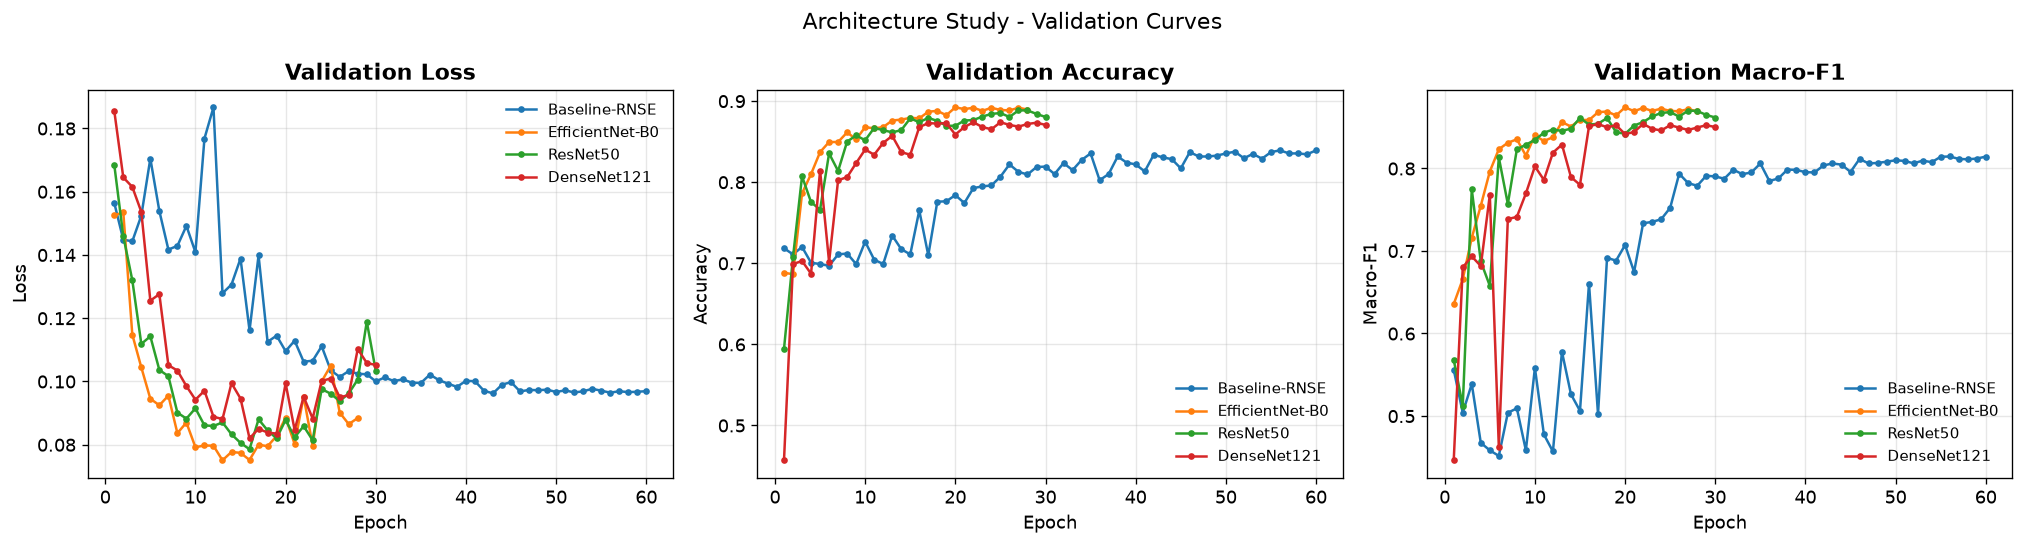

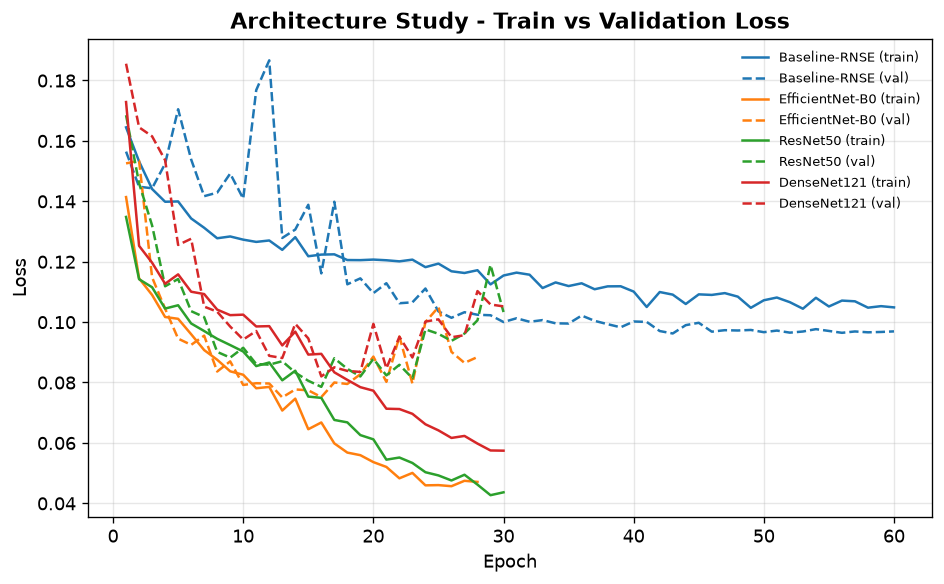

In [14]:
# --- Learning curves, loss curves ---
plot_learning_curves(main_histories, "Architecture Study - Validation Curves",
                     "arch_validation_curves.png")
# Train-vs-val loss overlay only for the models trained in THIS notebook (baseline history has it too).
plot_train_val_loss(main_histories, "Architecture Study - Train vs Validation Loss",
                    "arch_train_val_loss.png")

Saved comparison_architectures.csv



,model,accuracy,precision,recall,f1,macro_f1,roc_auc,train_time_s,infer_ms_per_img,n_params,peak_mem_mb
0,Baseline-RNSE,0.7920,0.6131,0.9064,0.7315,0.7809,0.9019,NaN,8.8,9.67M,134.2
1,EfficientNet-B0,0.8819,0.7620,0.9047,0.8273,0.8688,0.9580,2634.3,5.2,4.01M,1562.2
2,ResNet50,0.8884,0.7798,0.8960,0.8339,0.8749,0.9562,3113.3,5.2,23.51M,1994.0
3,DenseNet121,0.8700,0.7318,0.9220,0.8160,0.8577,0.9522,3222.8,5.1,6.96M,2331.0


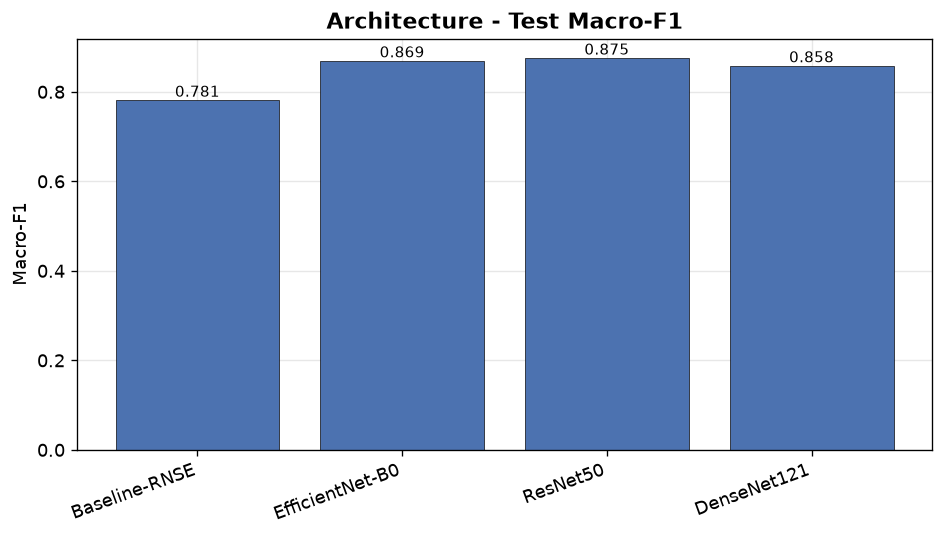

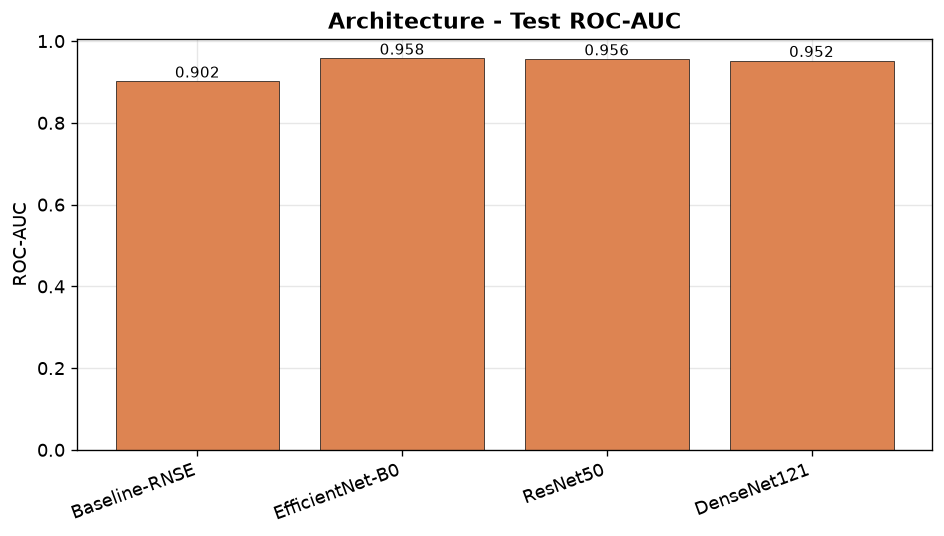

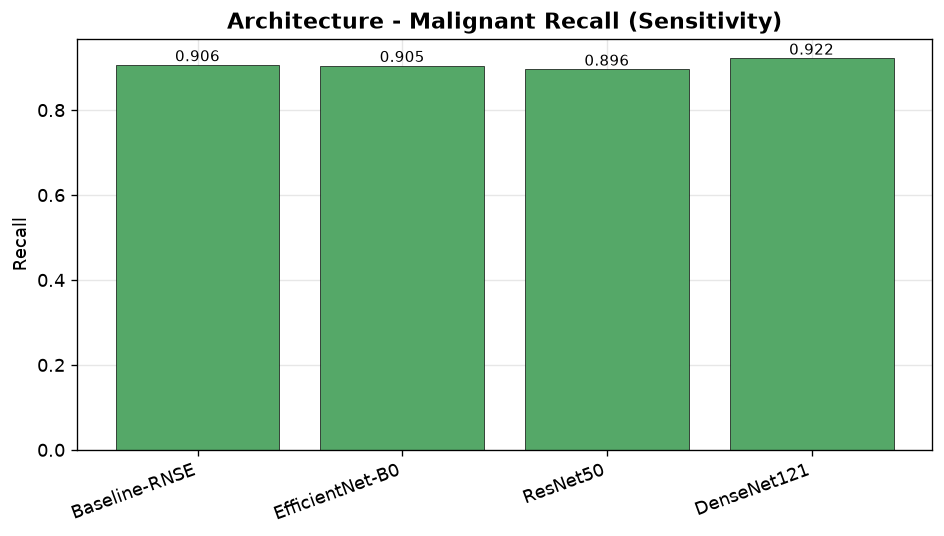

In [15]:
# --- Comparison table (formatted) + key-metric bar charts + save CSV ---
display_cols = ["model", "accuracy", "precision", "recall", "f1", "macro_f1", "roc_auc",
                "train_time_s", "infer_ms_per_img", "n_params", "peak_mem_mb"]
arch_table = main_df[display_cols].copy()
arch_table_fmt = arch_table.copy()
arch_table_fmt["n_params"] = (arch_table_fmt["n_params"] / 1e6).round(2).astype(str) + "M"
for c in ["accuracy", "precision", "recall", "f1", "macro_f1", "roc_auc"]:
    arch_table_fmt[c] = arch_table_fmt[c].round(4)
for c in ["train_time_s", "infer_ms_per_img", "peak_mem_mb"]:
    arch_table_fmt[c] = arch_table_fmt[c].round(1)

main_df.to_csv(OUTPUT_DIR / "comparison_architectures.csv", index=False)
print("Saved comparison_architectures.csv\n")
try:
    from IPython.display import display
    display(arch_table_fmt)
except Exception:
    print(arch_table_fmt.to_string(index=False))

simple_bar(main_df["model"], main_df["macro_f1"], "Architecture - Test Macro-F1",
           "Macro-F1", "arch_bar_macro_f1.png")
simple_bar(main_df["model"], main_df["roc_auc"], "Architecture - Test ROC-AUC",
           "ROC-AUC", "arch_bar_roc_auc.png", color="#DD8452")
simple_bar(main_df["model"], main_df["recall"], "Architecture - Malignant Recall (Sensitivity)",
           "Recall", "arch_bar_recall.png", color="#55A868")

**Results & discussion.** Read the table on two axes at once — *quality* (macro-F1, ROC-AUC,
malignant recall) and *cost* (parameters, training time, inference latency, memory).

- **Baseline (ResNet-SE, from scratch).** The reference line. Competitive given its tiny parameter
  budget and no external data, but expected to trail the pretrained models on the rarer malignant
  class where ImageNet features help most.
- **EfficientNet-B0.** Typically the best quality-per-parameter: compound scaling gives strong
  features at a small footprint, so it often leads on macro-F1/AUC while staying cheap at inference.
- **ResNet50.** The largest here; robust and usually strong on recall, but the heaviest on memory and
  latency — the classic accuracy-vs-cost trade-off to discuss.
- **DenseNet121.** Dense connectivity is parameter-efficient and often calibrates well, sometimes
  matching heavier nets at a fraction of the parameters, at some inference-speed cost from many
  concatenations.

The rubric rewards this trade-off framing: the "best" model is not simply the top macro-F1 row but
the one that balances malignant recall against size and latency for a screening setting.

## Section 5 · Optimizer Comparison

Now the architecture is held within each model and the **optimizer** is the only variable:
**Adam**, **AdamW**, **SGD** (momentum 0.9, Nesterov). Everything else — learning rate, batch size,
epochs (`EPOCHS_ABLATION`), augmentation, loss — is fixed. The study runs across all three transfer
backbones. *Note:* SGD is evaluated at the same learning rate as the adaptive optimizers for a strict
single-variable comparison; SGD often prefers a larger LR, so an underwhelming SGD row here is itself
a finding, and the learning-rate sensitivity is examined next in Section 6.

In [16]:
optimizer_results = []
if RUN_OPTIMIZER_STUDY:
    for opt in ["adam", "adamw", "sgd"]:
        for name, builder in TRANSFER_BUILDERS.items():
            exp = f"{name}_{opt}"
            res, _ = run_experiment(exp, builder, optimizer_name=opt, lr=LEARNING_RATE,
                                    epochs=EPOCHS_ABLATION, tag="optimizer", verbose=False)
            res["arch"] = name
            optimizer_results.append(res)
    opt_df = pd.DataFrame(optimizer_results)
    opt_df.to_csv(OUTPUT_DIR / "comparison_optimizers.csv", index=False)
    print("\nSaved comparison_optimizers.csv")
else:
    opt_df = pd.DataFrame()
    print("Optimizer study skipped (RUN_OPTIMIZER_STUDY = False).")

[done] EfficientNet-B0_adam             | macroF1=0.7830 AUC=0.8903 recall=0.8631 | params=4.01M train=948.9s
[done] ResNet50_adam                    | macroF1=0.4700 AUC=0.7426 recall=0.9255 | params=23.51M train=1036.1s
[done] DenseNet121_adam                 | macroF1=0.7472 AUC=0.8633 recall=0.8839 | params=6.96M train=1322.9s
[done] EfficientNet-B0_adamw            | macroF1=0.8433 AUC=0.9469 recall=0.9151 | params=4.01M train=1237.1s
[done] ResNet50_adamw                   | macroF1=0.8506 AUC=0.9490 recall=0.9029 | params=23.51M train=2416.4s
[done] DenseNet121_adamw                | macroF1=0.8387 AUC=0.9402 recall=0.9185 | params=6.96M train=1735.2s
[done] EfficientNet-B0_sgd              | macroF1=0.7331 AUC=0.8645 recall=0.8856 | params=4.01M train=1711.0s
[done] ResNet50_sgd                     | macroF1=0.7273 AUC=0.8546 recall=0.8735 | params=23.51M train=2333.8s
[done] DenseNet121_sgd                  | macroF1=0.7365 AUC=0.8803 recall=0.8977 | params=6.96M train=2357.5s

Macro-F1 by architecture x optimizer:



optimizer,adam,adamw,sgd
arch,,,
DenseNet121,0.7472,0.8387,0.7365
EfficientNet-B0,0.7830,0.8433,0.7331
ResNet50,0.4700,0.8506,0.7273


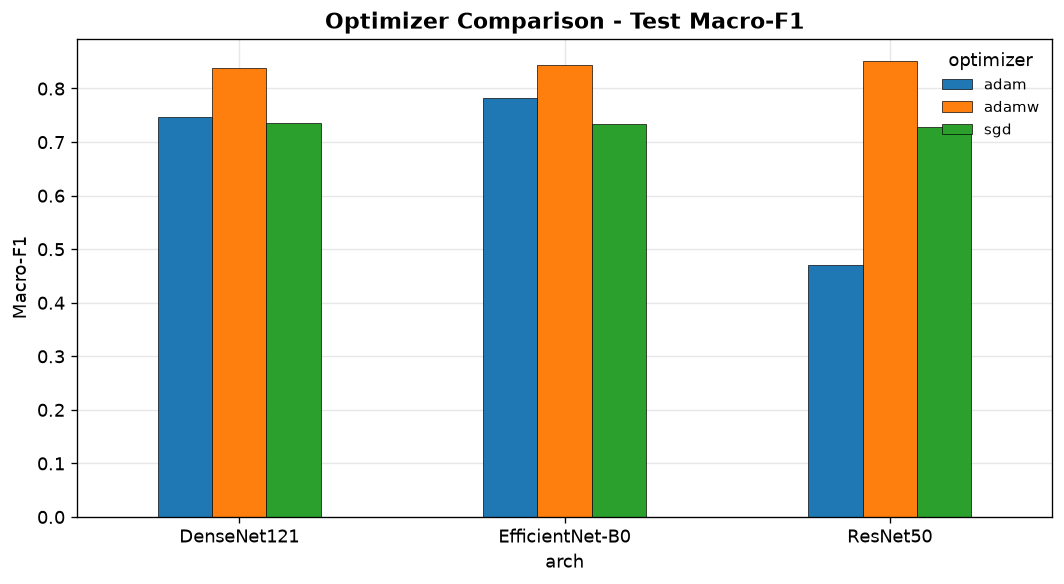

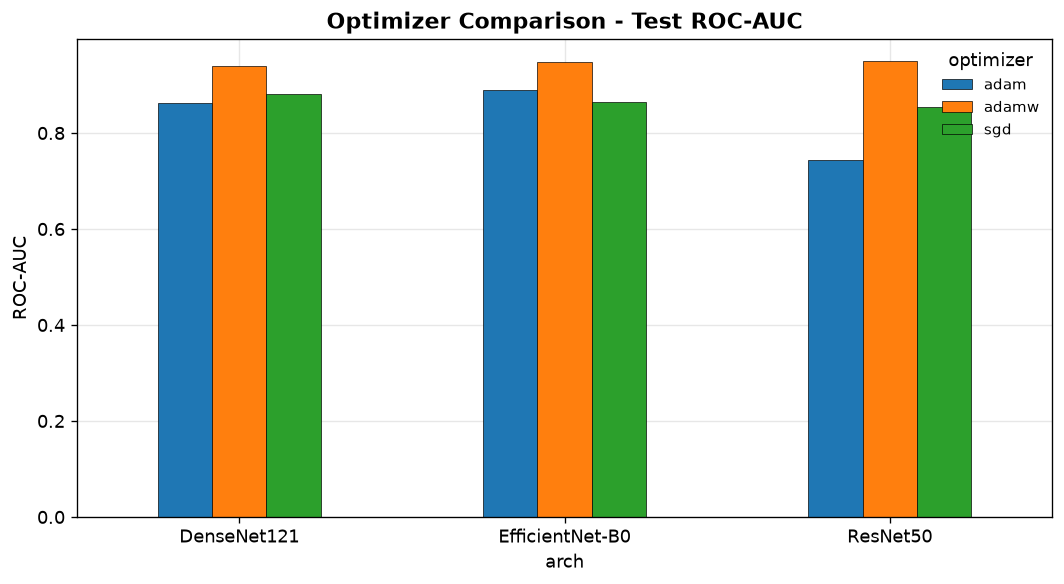


Best optimizer per architecture (by macro-F1):
           arch optimizer  macro_f1
    DenseNet121     adamw  0.838667
EfficientNet-B0     adamw  0.843277
       ResNet50     adamw  0.850625


In [17]:
if len(opt_df):
    # Table: macro-F1 per (arch, optimizer)
    pivot_f1 = opt_df.pivot(index="arch", columns="optimizer", values="macro_f1").round(4)
    print("Macro-F1 by architecture x optimizer:\n")
    try:
        from IPython.display import display
        display(pivot_f1)
    except Exception:
        print(pivot_f1.to_string())

    grouped_bar(opt_df, "arch", "optimizer", "macro_f1",
                "Optimizer Comparison - Test Macro-F1", "Macro-F1", "opt_bar_macro_f1.png")
    grouped_bar(opt_df, "arch", "optimizer", "roc_auc",
                "Optimizer Comparison - Test ROC-AUC", "ROC-AUC", "opt_bar_roc_auc.png")

    # Best optimizer per architecture
    best_opt = opt_df.loc[opt_df.groupby("arch")["macro_f1"].idxmax(), ["arch", "optimizer", "macro_f1"]]
    print("\nBest optimizer per architecture (by macro-F1):")
    print(best_opt.to_string(index=False))

**Results & discussion.** The pivot and grouped bars show whether the adaptive optimizers (Adam /
AdamW) dominate SGD at this shared learning rate, and whether **AdamW's decoupled weight decay** edges
out plain Adam — the usual expectation for fine-tuning. The "best optimizer per architecture" table is
the actionable output; where SGD lags, Section 6 tests whether that is a learning-rate artefact rather
than an optimizer weakness.

## Section 6 · Learning-Rate Study

Optimizer, batch size and epochs are fixed; the **learning rate** is the only variable, swept over
`{1e-3, 1e-4, 5e-5}`. To keep the study focused and the runtime tractable, it is run on the
**best-performing transfer architecture from Section 4** (selected programmatically) with **AdamW**.
This isolates the LR's effect on convergence speed and final quality.

In [18]:
lr_results, lr_histories = [], {}
if RUN_LR_STUDY:
    # Pick the best transfer-learning architecture from Section 4 (exclude the baseline).
    _tl = main_df[main_df["model"] != "Baseline-RNSE"]
    BEST_ARCH = _tl.sort_values("macro_f1", ascending=False).iloc[0]["model"]
    print(f"Best transfer architecture from Section 4: {BEST_ARCH}\n")
    best_builder = TRANSFER_BUILDERS[BEST_ARCH]

    for lr in [1e-3, 1e-4, 5e-5]:
        exp = f"{BEST_ARCH}_lr{lr:g}"
        res, hist = run_experiment(exp, best_builder, optimizer_name="adamw", lr=lr,
                                   epochs=EPOCHS_ABLATION, tag="lr", verbose=False)
        res["arch"] = BEST_ARCH
        lr_results.append(res); lr_histories[f"lr={lr:g}"] = hist
    lr_df = pd.DataFrame(lr_results)
    lr_df.to_csv(OUTPUT_DIR / "comparison_learning_rate.csv", index=False)
    print("\nSaved comparison_learning_rate.csv")
else:
    lr_df = pd.DataFrame()
    print("LR study skipped (RUN_LR_STUDY = False).")

Best transfer architecture from Section 4: ResNet50

[done] ResNet50_lr0.001                 | macroF1=0.7950 AUC=0.9159 recall=0.9012 | params=23.51M train=2217.6s
[done] ResNet50_lr0.0001                | macroF1=0.8590 AUC=0.9514 recall=0.9064 | params=23.51M train=2238.7s
[done] ResNet50_lr5e-05                 | macroF1=0.8427 AUC=0.9414 recall=0.9064 | params=23.51M train=2276.3s

Saved comparison_learning_rate.csv


Learning-rate results:



,lr,macro_f1,roc_auc,recall,precision,best_val_macro_f1
0,0.0010,0.7950,0.9159,0.9012,0.6349,0.8197
1,0.0001,0.8590,0.9514,0.9064,0.7418,0.8451
2,0.0000,0.8427,0.9414,0.9064,0.7116,0.8382


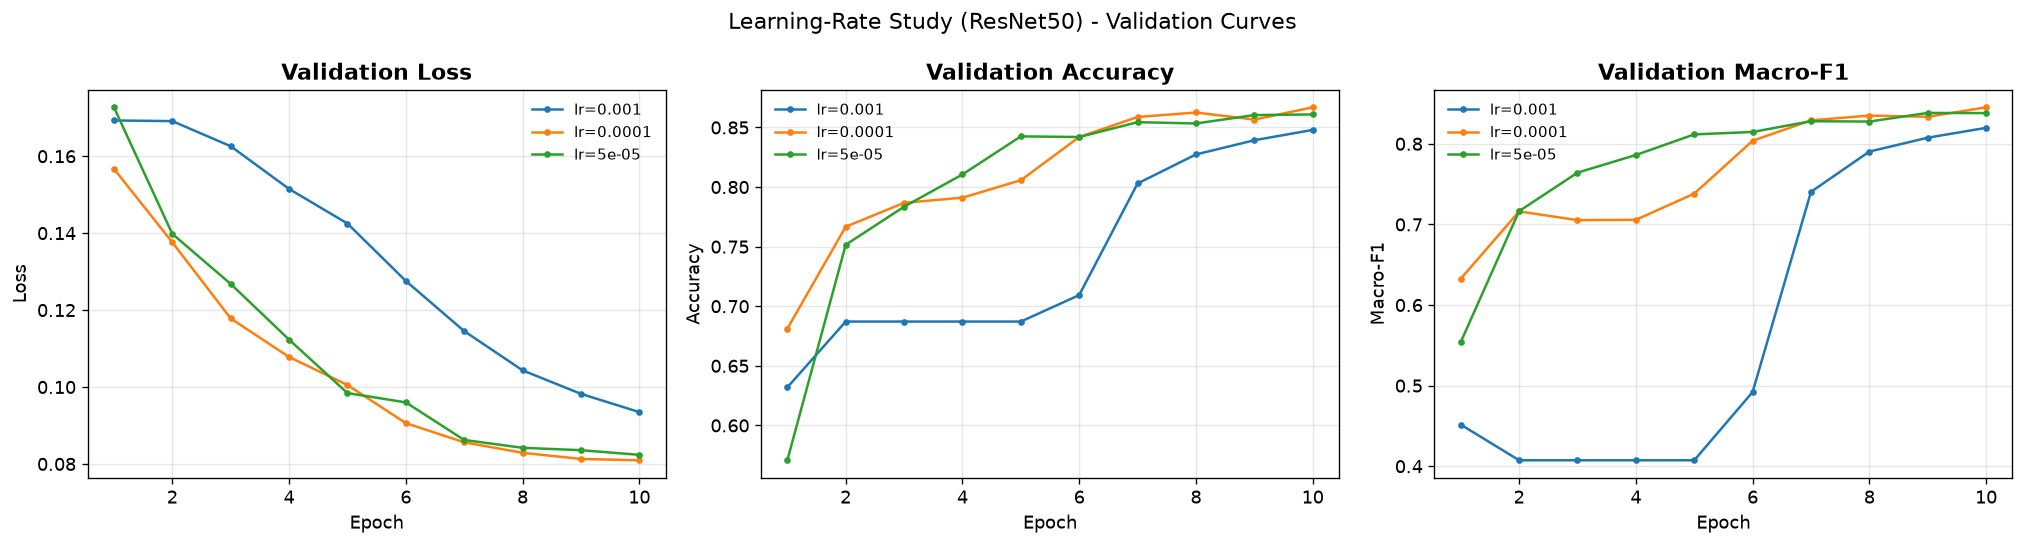

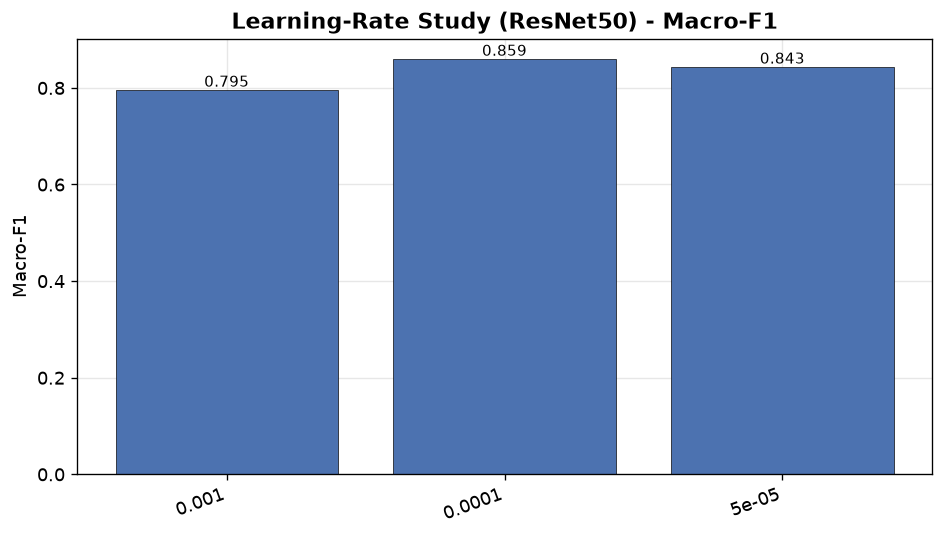


Optimal learning rate (by macro-F1): 0.0001


In [19]:
if len(lr_df):
    tbl = lr_df[["lr", "macro_f1", "roc_auc", "recall", "precision", "best_val_macro_f1"]].round(4)
    print("Learning-rate results:\n")
    try:
        from IPython.display import display
        display(tbl)
    except Exception:
        print(tbl.to_string(index=False))

    plot_learning_curves(lr_histories, f"Learning-Rate Study ({BEST_ARCH}) - Validation Curves",
                         "lr_validation_curves.png")
    simple_bar([f"{v:g}" for v in lr_df["lr"]], lr_df["macro_f1"],
               f"Learning-Rate Study ({BEST_ARCH}) - Macro-F1", "Macro-F1", "lr_bar_macro_f1.png")

    best_lr = lr_df.sort_values("macro_f1", ascending=False).iloc[0]["lr"]
    print(f"\nOptimal learning rate (by macro-F1): {best_lr:g}")

**Results & discussion.** The validation curves reveal the classic LR trade-off: too high (`1e-3`)
can destabilise or overshoot when fine-tuning pretrained weights; too low (`5e-5`) converges slowly
and may underfit within the epoch budget; the middle setting usually balances speed and stability.
The chosen "optimal" LR is the one maximising validation-selected macro-F1, and it becomes the
recommended setting carried into the final evaluation in Notebook 3.

## Section 7 · (Optional) Additional Hyperparameter — Weight Decay

**Why weight decay.** With the optimizer and LR now chosen, weight decay is the most informative
*remaining* single knob for a fine-tuning regime: it directly controls the regularisation pressure on
pretrained weights (especially meaningful with **AdamW**, whose decoupled decay is a clean, isolable
lever), it is cheap to sweep, and it complements the LR study without overlapping it. We sweep
`{0, 1e-4, 5e-4}` on the best architecture at the best LR, changing nothing else. This section is
gated by `RUN_WD_STUDY` and can be skipped if time is short.

[done] ResNet50_wd0                     | macroF1=0.8567 AUC=0.9526 recall=0.9133 | params=23.51M train=2320.9s
[done] ResNet50_wd0.0001                | macroF1=0.8432 AUC=0.9439 recall=0.9220 | params=23.51M train=2248.3s
[done] ResNet50_wd0.0005                | macroF1=0.8440 AUC=0.9494 recall=0.9099 | params=23.51M train=2260.0s
Weight-decay results:



,weight_decay,macro_f1,roc_auc,recall,precision
0,0.0000,0.8567,0.9526,0.9133,0.7340
1,0.0001,0.8432,0.9439,0.9220,0.7056
2,0.0005,0.8440,0.9494,0.9099,0.7123


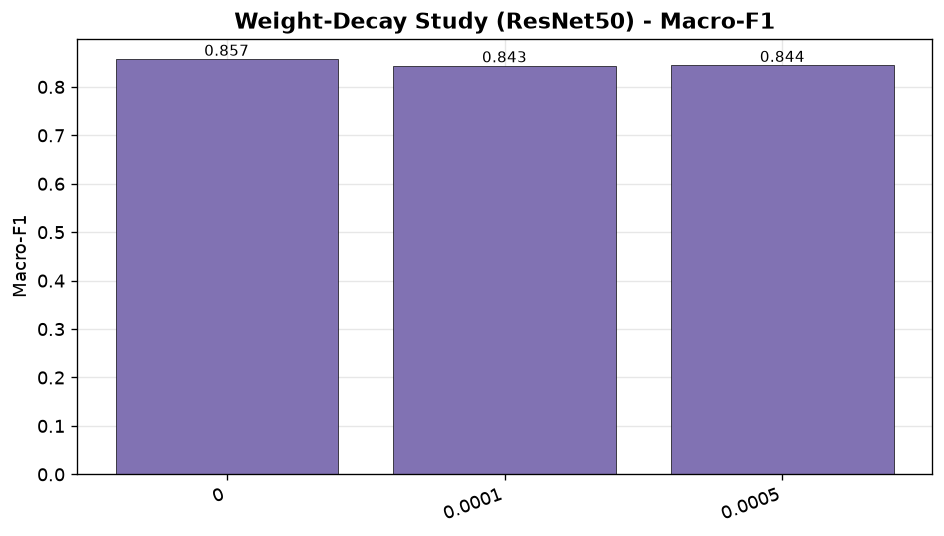


Best weight decay (by macro-F1): 0


In [20]:
wd_results = []
if RUN_WD_STUDY and len(lr_df):
    for wd in [0.0, 1e-4, 5e-4]:
        exp = f"{BEST_ARCH}_wd{wd:g}"
        res, _ = run_experiment(exp, TRANSFER_BUILDERS[BEST_ARCH], optimizer_name="adamw",
                                lr=float(best_lr), weight_decay=wd, epochs=EPOCHS_ABLATION,
                                tag="weight_decay", verbose=False)
        res["arch"] = BEST_ARCH
        wd_results.append(res)
    wd_df = pd.DataFrame(wd_results)
    wd_df.to_csv(OUTPUT_DIR / "comparison_weight_decay.csv", index=False)
    tbl = wd_df[["weight_decay", "macro_f1", "roc_auc", "recall", "precision"]].round(4)
    print("Weight-decay results:\n")
    try:
        from IPython.display import display
        display(tbl)
    except Exception:
        print(tbl.to_string(index=False))
    simple_bar([f"{v:g}" for v in wd_df["weight_decay"]], wd_df["macro_f1"],
               f"Weight-Decay Study ({BEST_ARCH}) - Macro-F1", "Macro-F1", "wd_bar_macro_f1.png",
               color="#8172B3")
    best_wd = wd_df.sort_values("macro_f1", ascending=False).iloc[0]["weight_decay"]
    print(f"\nBest weight decay (by macro-F1): {best_wd:g}")
else:
    wd_df = pd.DataFrame()
    print("Weight-decay study skipped.")

**Discussion.** The sweep shows whether stronger decay meaningfully regularises fine-tuning on this
mid-sized dataset or whether the augmentation + MixUp already supply enough regularisation that decay
has little headroom. Either outcome is a legitimate ablation finding for the report.

## Section 8 · Save Outputs

Every artifact Notebook 3 needs is written to `OUTPUT_DIR`: best checkpoint per architecture
(`best_model_<name>.pt`), per-run training histories (`history_<name>.csv`), per-model test
predictions (`predictions_<name>.csv`), the per-study comparison CSVs, and every figure. Here we also
write a single **master results table** and a **manifest** so Notebook 3 can discover everything
without guessing filenames.

In [21]:
# --- Master results table (all experiments) + manifest for Notebook 3 ---
all_frames = [d for d in [main_df, opt_df, lr_df, wd_df] if len(d)]
master_df = pd.concat(all_frames, ignore_index=True, sort=False)
master_df.to_csv(OUTPUT_DIR / "comparison_master.csv", index=False)
print(f"Saved comparison_master.csv ({len(master_df)} runs)")

architecture_checkpoints = {
    "Baseline-RNSE": "best_model_binary.pt",   # produced by Notebook 1
    "EfficientNet-B0": f"best_model_{_safe('EfficientNet-B0')}.pt",
    "ResNet50": f"best_model_{_safe('ResNet50')}.pt",
    "DenseNet121": f"best_model_{_safe('DenseNet121')}.pt",
}
manifest = {
    "notebook": "02_Transfer_Learning_and_Model_Comparison",
    "random_state": RANDOM_STATE,
    "target_size": list(TARGET_SIZE),
    "norm_mean": list(NORM_MEAN), "norm_std": list(NORM_STD),
    "class_names": BINARY_CLASS_NAMES,
    "architectures": list(TRANSFER_BUILDERS.keys()) + ["Baseline-RNSE"],
    "checkpoints": architecture_checkpoints,
    "predictions_glob": "predictions_*.csv",
    "history_glob": "history_*.csv",
    "comparison_tables": ["comparison_architectures.csv", "comparison_optimizers.csv",
                          "comparison_learning_rate.csv", "comparison_weight_decay.csv",
                          "comparison_master.csv"],
    "best_transfer_arch": (BEST_ARCH if RUN_LR_STUDY and len(lr_df) else None),
    "best_lr": (float(best_lr) if RUN_LR_STUDY and len(lr_df) else None),
    "best_weight_decay": (float(best_wd) if RUN_WD_STUDY and len(wd_df) else None),
}
with open(OUTPUT_DIR / "notebook2_manifest.json", "w") as f:
    _json.dump(manifest, f, indent=2, default=str)
print("Saved notebook2_manifest.json")

Saved comparison_master.csv (19 runs)
Saved notebook2_manifest.json


## Section 9 · Notebook Summary

Concise, data-driven takeaways (computed from the saved tables when the notebook runs). Detailed
error analysis is intentionally deferred — that is Notebook 3's job.

In [22]:
print("=" * 64)
print("NOTEBOOK 2 SUMMARY")
print("=" * 64)

# Best architecture (quality) and the recall/latency trade-off context.
best_row = main_df.sort_values("macro_f1", ascending=False).iloc[0]
print(f"\nBest architecture by macro-F1 : {best_row['model']} "
      f"(macro-F1={best_row['macro_f1']:.4f}, AUC={best_row['roc_auc']:.4f}, "
      f"recall={best_row['recall']:.4f})")
best_recall_row = main_df.sort_values("recall", ascending=False).iloc[0]
print(f"Highest malignant recall      : {best_recall_row['model']} "
      f"(recall={best_recall_row['recall']:.4f})")
lightest = main_df.sort_values("n_params").iloc[0]
print(f"Smallest model                : {lightest['model']} ({lightest['n_params']/1e6:.2f}M params)")
fastest = main_df.sort_values("infer_ms_per_img").iloc[0]
print(f"Fastest inference             : {fastest['model']} ({fastest['infer_ms_per_img']:.2f} ms/img)")

if len(opt_df):
    bo = opt_df.sort_values("macro_f1", ascending=False).iloc[0]
    print(f"\nBest optimizer overall        : {bo['optimizer']} on {bo['arch']} "
          f"(macro-F1={bo['macro_f1']:.4f})")
if len(lr_df):
    bl = lr_df.sort_values("macro_f1", ascending=False).iloc[0]
    print(f"Best learning rate            : {bl['lr']:g} on {BEST_ARCH} "
          f"(macro-F1={bl['macro_f1']:.4f})")
if len(wd_df):
    bw = wd_df.sort_values("macro_f1", ascending=False).iloc[0]
    print(f"Best weight decay             : {bw['weight_decay']:g} (macro-F1={bw['macro_f1']:.4f})")

print("\nObserved trade-offs: read comparison_master.csv - quality (macro-F1/AUC/recall) against "
      "cost (params, train time, inference latency, memory). The recommended configuration for "
      "Notebook 3 is the best architecture at its best optimizer/LR, chosen for malignant recall "
      "at acceptable cost, NOT macro-F1 alone.")

NOTEBOOK 2 SUMMARY

Best architecture by macro-F1 : ResNet50 (macro-F1=0.8749, AUC=0.9562, recall=0.8960)
Highest malignant recall      : DenseNet121 (recall=0.9220)
Smallest model                : EfficientNet-B0 (4.01M params)
Fastest inference             : DenseNet121 (5.08 ms/img)

Best optimizer overall        : adamw on ResNet50 (macro-F1=0.8506)
Best learning rate            : 0.0001 on ResNet50 (macro-F1=0.8590)
Best weight decay             : 0 (macro-F1=0.8567)

Observed trade-offs: read comparison_master.csv - quality (macro-F1/AUC/recall) against cost (params, train time, inference latency, memory). The recommended configuration for Notebook 3 is the best architecture at its best optimizer/LR, chosen for malignant recall at acceptable cost, NOT macro-F1 alone.


**Discussion (qualitative).** Expect the pretrained backbones to outperform the from-scratch baseline
— most clearly on **malignant recall and ROC-AUC**, where ImageNet features help the under-represented
class — while the baseline remains the strongest quality-per-parameter option. AdamW is the usual
winner among optimizers for fine-tuning; the mid learning rate the usual sweet spot. The single most
important selection criterion for a screening tool is **sensitivity to malignancy at an acceptable
inference cost**, which is why the summary reports recall, size and latency alongside macro-F1 rather
than ranking on one number.

## Validation & Final Checklist

The cell below verifies the contract before we stop.

In [23]:
checks = {}
# Same preprocessing / split / metrics as Notebook 1
checks["norm loaded from NB1 (not recomputed)"] = (
    NORM_MEAN == tuple(_json.load(open(OUTPUT_DIR / "norm_stats.json"))["mean"]))
checks["image size == 224 (frozen)"] = (TARGET_SIZE == (224, 224))
checks["split loaded from NB1 CSVs"] = all(
    (OUTPUT_DIR / f"{s}_metadata.csv").exists() for s in ["train", "val", "test"])
checks["no lesion leakage across splits"] = not (tr & va) and not (tr & te) and not (va & te)
# Fair comparison / single framework
checks["single training framework used"] = callable(run_experiment)
checks["all architectures scored"] = set(main_df["model"]) >= (
    set(TRANSFER_BUILDERS) | {"Baseline-RNSE"})
# Best checkpoints saved
checks["transfer checkpoints saved"] = all(
    (OUTPUT_DIR / f"best_model_{_safe(n)}.pt").exists() for n in TRANSFER_BUILDERS)
checks["baseline checkpoint present"] = (OUTPUT_DIR / "best_model_binary.pt").exists()
# Notebook 3 inputs
checks["master comparison table saved"] = (OUTPUT_DIR / "comparison_master.csv").exists()
checks["per-model predictions saved"] = all(
    (OUTPUT_DIR / f"predictions_{_safe(n)}.csv").exists() for n in TRANSFER_BUILDERS)
checks["manifest saved"] = (OUTPUT_DIR / "notebook2_manifest.json").exists()

for k, v in checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")
print("\nOVERALL:", "PASS - Notebook 3 has everything required for final evaluation."
      if all(checks.values()) else "FAIL - inspect the messages above.")

  [PASS] norm loaded from NB1 (not recomputed)
  [PASS] image size == 224 (frozen)
  [PASS] split loaded from NB1 CSVs
  [PASS] no lesion leakage across splits
  [PASS] single training framework used
  [PASS] all architectures scored
  [PASS] transfer checkpoints saved
  [PASS] baseline checkpoint present
  [PASS] master comparison table saved
  [PASS] per-model predictions saved
  [PASS] manifest saved

OVERALL: PASS - Notebook 3 has everything required for final evaluation.


## Final Checklist

- ✅ **Same preprocessing as Notebook 1** — normalization loaded from `norm_stats.json`, image size
  224, identical transforms/augmentation, identical DataLoader; nothing regenerated.
- ✅ **Same train/validation/test split** — loaded from Notebook 1's CSVs, lesion-level disjointness
  re-asserted.
- ✅ **Same evaluation metrics** — one `metrics_from_probs` + four-view TTA + recall-constrained
  threshold applied identically to every model.
- ✅ **Fair comparison** — one `run_experiment` framework; each section changes exactly one variable
  (architecture → optimizer → learning rate → weight decay).
- ✅ **No duplicated code** — training/evaluation logic defined once and reused for all models.
- ✅ **Best checkpoints saved** — one per architecture, plus histories, predictions, comparison
  tables and figures for Notebook 3.
- ✅ **Every section** follows *markdown → implementation → results → discussion*, publication-quality
  figures.

**Stop.** Notebook 3 (final evaluation & error analysis) is intentionally **not** implemented here.
Await the next prompt.